In [1]:
import sys
sys.path.append('../src')

In [2]:
from matplotlib import pyplot as plt
from tqdm.notebook import tqdm
import numpy as np

In [3]:
from context import TriangleIntegrandContext
from integrand_builder import IntegrandBuilder

from context import TriangleIntegrandEvaluator
from wrapped_eval import WrappedEvaluator

ctx = TriangleIntegrandContext()

ib = IntegrandBuilder()
ib.check_singularities_per_sample = True # not necessary for this example, improves performance
ib.center_counterterm_region_at_origin = False
ib.smooth_mask = True

ib_variable = IntegrandBuilder()
ib_variable.check_singularities_per_sample = True # not necessary for this example, improves performance
ib_variable.center_counterterm_region_at_origin = False
ib_variable.smooth_mask = True
ib_variable.use_complex_dist = True

real_dist = TriangleIntegrandEvaluator(
    WrappedEvaluator(ib.combined_result(), ib.get_args(), "smooth"), ctx
)

complex_dist = TriangleIntegrandEvaluator(
    WrappedEvaluator(ib.combined_result(), ib.get_args(), "variable_smooth"), ctx
)

Compiling evaluator: "smooth"
Done!
Compiling evaluator: "variable_smooth"
Done!


In [4]:
from symbolica import RandomNumberGenerator


rng = RandomNumberGenerator(0,0)

In [5]:
from context import spherical
from integrator import ComplexIntegrator


def integrate_over_masses(masses, triangle, epochs = 100, steps = 500):
    results = []
    for m in tqdm(masses):
        ctx.masses = [m, m, m]
        
        ci = ComplexIntegrator(3)
        results.append(ci.integrate(triangle.eval, spherical, epochs, steps, rng))
        
        
    return results

def reference_over_masses(masses):
    ref = []
    for m in masses:
        ctx.masses = [m, m, m]
        ref.append(ctx.get_reference())
    return np.array(ref)

[np.float64(0.5), np.float64(0.8660254037844386), np.float64(1.414213562373095)]


<Figure size 2000x1000 with 0 Axes>

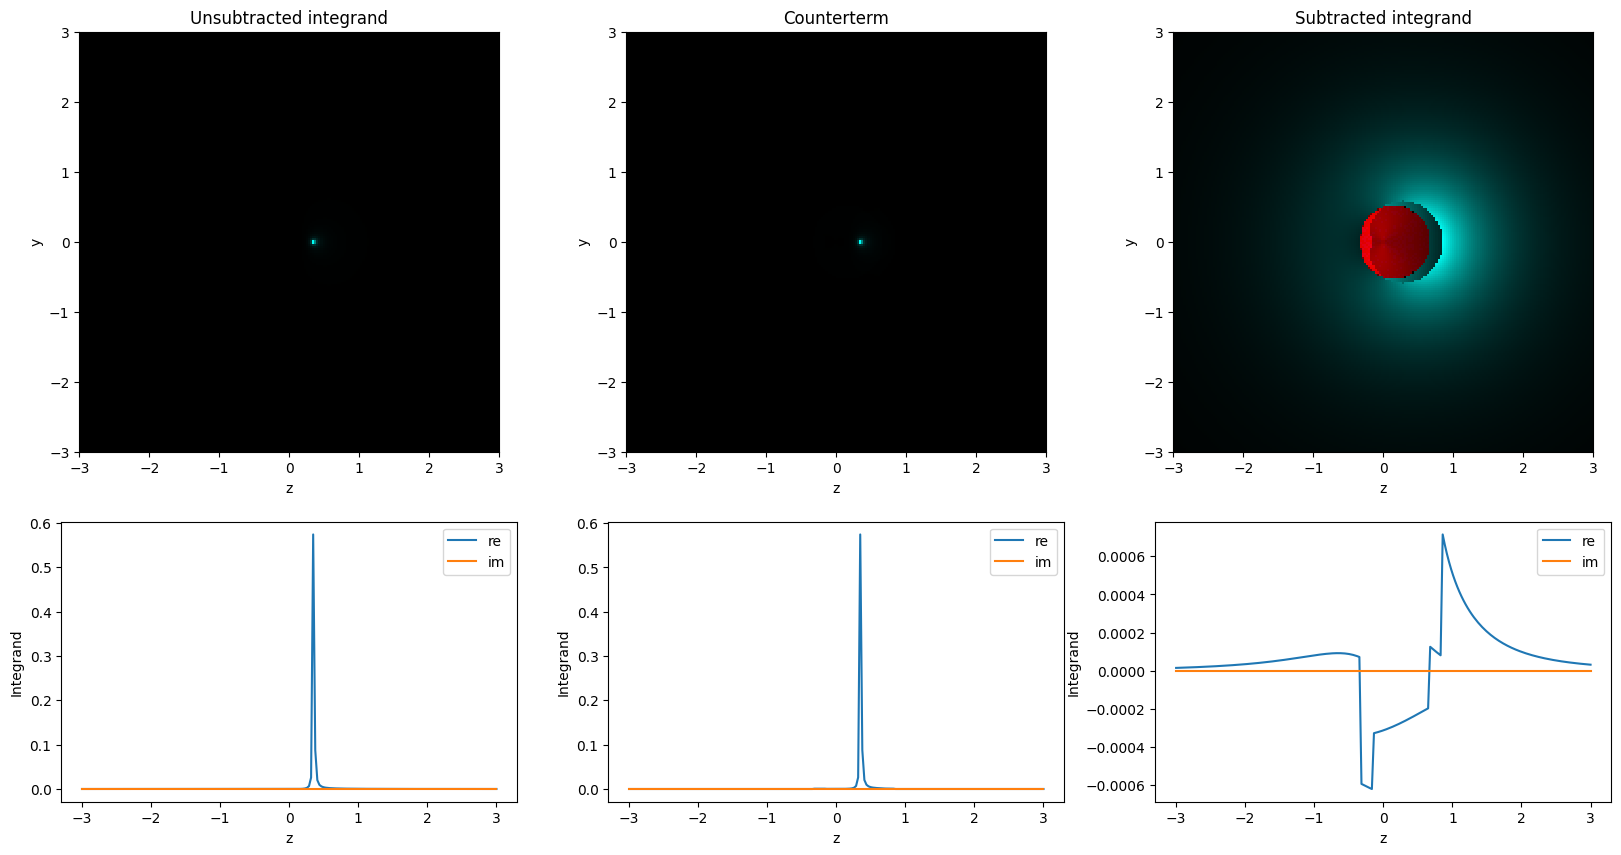

In [ ]:
from context import norm

ctx.set_external_momenta(1, 3, 8)
ctx.subtraction_width = 0.5
ctx.mask_width = 0.5


qs, _ = ctx.get_ordered_qs_and_masses()

threshold_masses = [norm((qs[i]-qs[j])/2)**0.5 for (i,j) in [(0,1), (1,2), (0,2)]]
threshold_masses.sort()


print(threshold_masses)

ctx.max_eta_min = 1e10

m = threshold_masses[2]+1e-5
ctx.masses = [m,m,m]
real_dist.plot_threshold_subtraction((-3,3),(-3,3), x_axis = 2)
plt.savefig(f"../images/threshold_masses/subtraction_of_imag_e_surf.png", dpi=300)
plt.show()

In [7]:
from symbolica import RandomNumberGenerator
rng = RandomNumberGenerator(0,0)

In [8]:
sample_masses = np.linspace(0.2,2,21)
ref_masses = np.linspace(0.2,2,200)

ctx.combined_integrand()
ctx.max_eta_min = 0
global_check_res = integrate_over_masses(sample_masses, real_dist)

ctx.max_eta_min = 1e10
per_sample_check = integrate_over_masses(sample_masses, real_dist)

if complex_dist is not None:
    complex_dist_res = integrate_over_masses(sample_masses, complex_dist)

ctx.only_unsubtracted()
unsubtracted_res = integrate_over_masses(sample_masses, real_dist)

ref = reference_over_masses(ref_masses)

  0%|          | 0/21 [00:00<?, ?it/s]

  0%|          | 0/21 [00:00<?, ?it/s]

  0%|          | 0/21 [00:00<?, ?it/s]

  0%|          | 0/21 [00:00<?, ?it/s]

########################################################################
#                                                                      #
#                        You are using OneLOop                         #
#                                                                      #
# for the evaluation of 1-loop scalar 1-, 2-, 3- and 4-point functions #
#                                                                      #
# author: Andreas van Hameren <hamerenREMOVETHIS@ifj.edu.pl>           #
#   date: 2024-11-23                                                   #
#                                                                      #
# Please cite                                                          #
#    A. van Hameren,                                                   #
#      Comput.Phys.Commun. 182 (2011) 2427-2438, arXiv:1007.4716       #
#    A. van Hameren, C.G. Papadopoulos and R. Pittau,                  #
#      JHEP 0909:106,2009, arXiv:0903.4665         

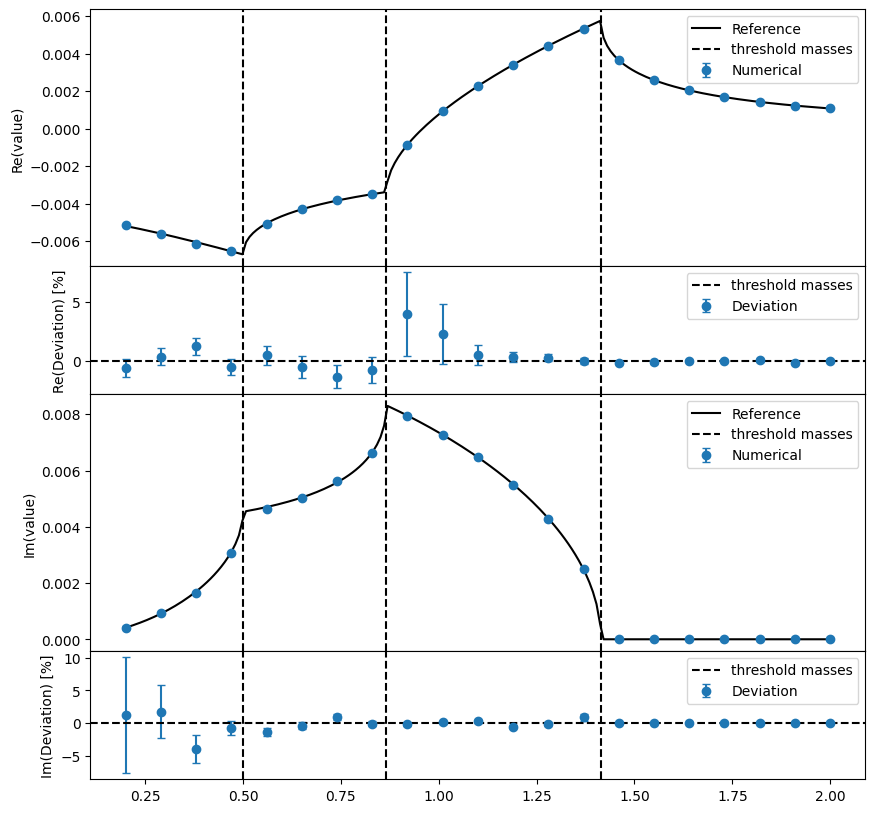

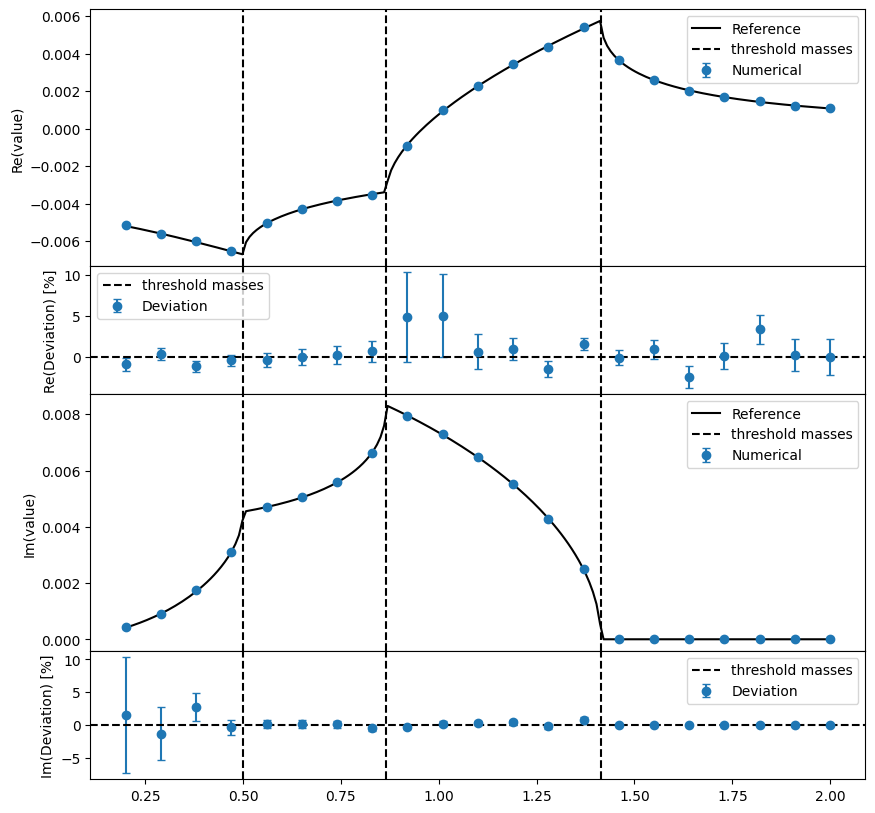

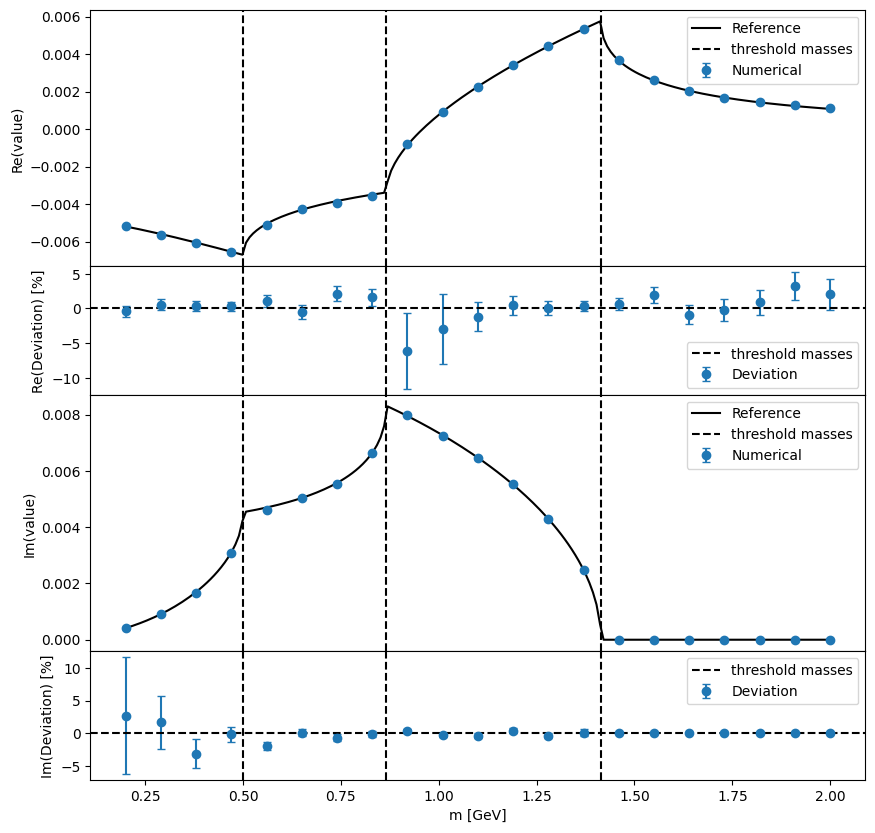

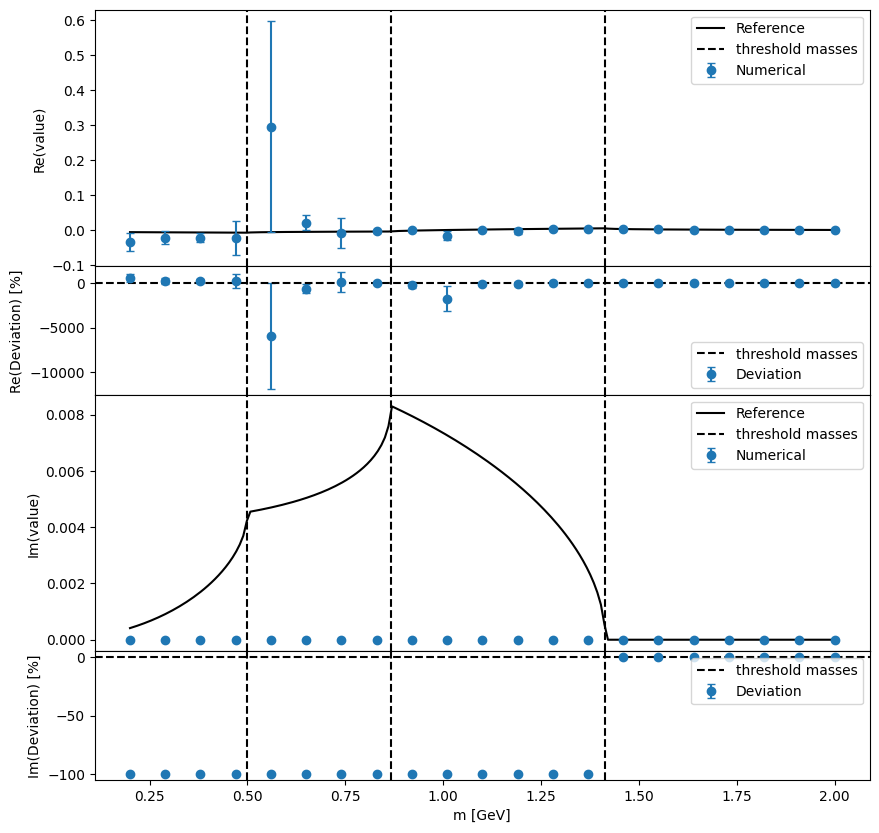

In [9]:
from plot_util import plot_complex_integration_with_ref


ref = reference_over_masses(ref_masses)
ref_same_x = reference_over_masses(sample_masses)

fig = plot_complex_integration_with_ref(
    global_check_res, ref_same_x, sample_masses, ref, ref_masses
)
for ax in fig.get_axes():
    ax.axvline(threshold_masses[0], ls = "--", c = "black", label = 'threshold masses')
    ax.axvline(threshold_masses[1], ls = "--", c = "black")
    ax.axvline(threshold_masses[2], ls = "--", c = "black")
    ax.legend()
plt.savefig(f"../images/threshold_masses/global_check.png", dpi=300)
plt.show()

fig = plot_complex_integration_with_ref(
    per_sample_check, ref_same_x, sample_masses, ref, ref_masses
)
for ax in fig.get_axes():
    ax.axvline(threshold_masses[0], ls = "--", c = "black", label = 'threshold masses')
    ax.axvline(threshold_masses[1], ls = "--", c = "black")
    ax.axvline(threshold_masses[2], ls = "--", c = "black")
    ax.legend()
plt.savefig(f"../images/threshold_masses/per_sample_check.png", dpi=300)
plt.show()
if complex_dist is not None:
    fig = plot_complex_integration_with_ref(
        complex_dist_res, ref_same_x, sample_masses, ref, ref_masses
    )
    for ax in fig.get_axes():
        ax.axvline(threshold_masses[0], ls = "--", c = "black", label = 'threshold masses')
        ax.axvline(threshold_masses[1], ls = "--", c = "black")
        ax.axvline(threshold_masses[2], ls = "--", c = "black")
        ax.legend()
    fig.get_axes()[-1].set_xlabel('m [GeV]')
    plt.savefig(f"../images/threshold_masses/variable.png", dpi=300)
    plt.show()


fig = plot_complex_integration_with_ref(
    unsubtracted_res, ref_same_x, sample_masses, ref, ref_masses
)
for ax in fig.get_axes():
    ax.axvline(threshold_masses[0], ls = "--", c = "black", label = 'threshold masses')
    ax.axvline(threshold_masses[1], ls = "--", c = "black")
    ax.axvline(threshold_masses[2], ls = "--", c = "black")
    ax.legend()
fig.get_axes()[-1].set_xlabel('m [GeV]')
plt.savefig(f"../images/threshold_masses/unsubtracted.png", dpi=300)
plt.show()

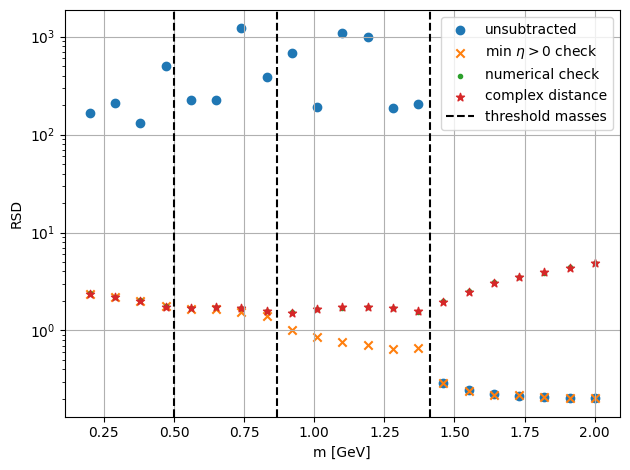

In [10]:
plt.scatter(sample_masses, [r.rsd() for r in unsubtracted_res], label = 'unsubtracted', marker='o')
plt.scatter(sample_masses, [r.rsd() for r in global_check_res], label = 'min $\\eta > 0$ check', marker = 'x')
plt.scatter(sample_masses, [r.rsd() for r in per_sample_check], label = 'numerical check', marker = '.')
if complex_dist is not None:
    plt.scatter(sample_masses, [r.rsd() for r in complex_dist_res], label = 'complex distance', marker = '*')
plt.yscale('log')
plt.axvline(threshold_masses[0], ls = "--", c = "black", label = 'threshold masses')
plt.axvline(threshold_masses[1], ls = "--", c = "black")
plt.axvline(threshold_masses[2], ls = "--", c = "black")

plt.grid(True)
plt.xlabel('m [GeV]')
plt.ylabel('RSD')
plt.legend()
plt.tight_layout()

plt.savefig(f"../images/threshold_masses/rsd.png", dpi=300)
plt.show()


In [11]:
c = np.sqrt(2)
d = 2e-4

ref_masses = np.linspace(c-d,c+d,200)
sample_masses = np.linspace(c-d,c+d,21)

ctx.combined_integrand()
ctx.max_eta_min = 0

global_check_res = integrate_over_masses(sample_masses, real_dist)
ctx.max_eta_min = 1e10
per_sample_check = integrate_over_masses(sample_masses, real_dist)
if complex_dist is not None:
    complex_dist_res = integrate_over_masses(sample_masses, complex_dist)

ctx.only_unsubtracted()
unsubtracted_res = integrate_over_masses(sample_masses, real_dist)

ref = reference_over_masses(ref_masses)

  0%|          | 0/21 [00:00<?, ?it/s]

  0%|          | 0/21 [00:00<?, ?it/s]

  0%|          | 0/21 [00:00<?, ?it/s]

  0%|          | 0/21 [00:00<?, ?it/s]

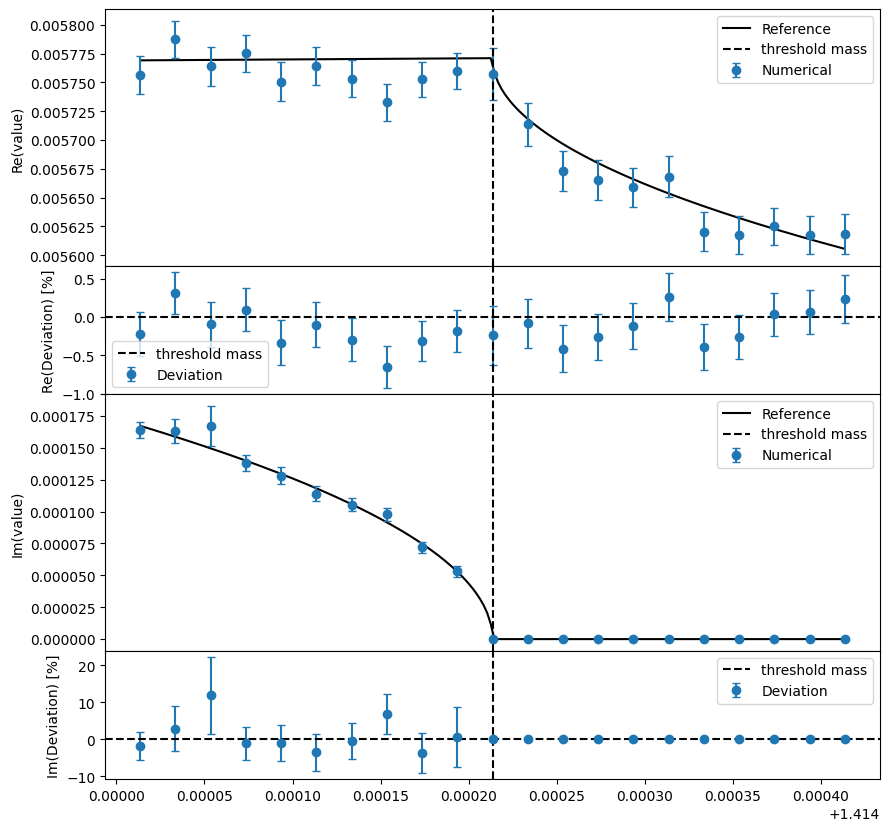

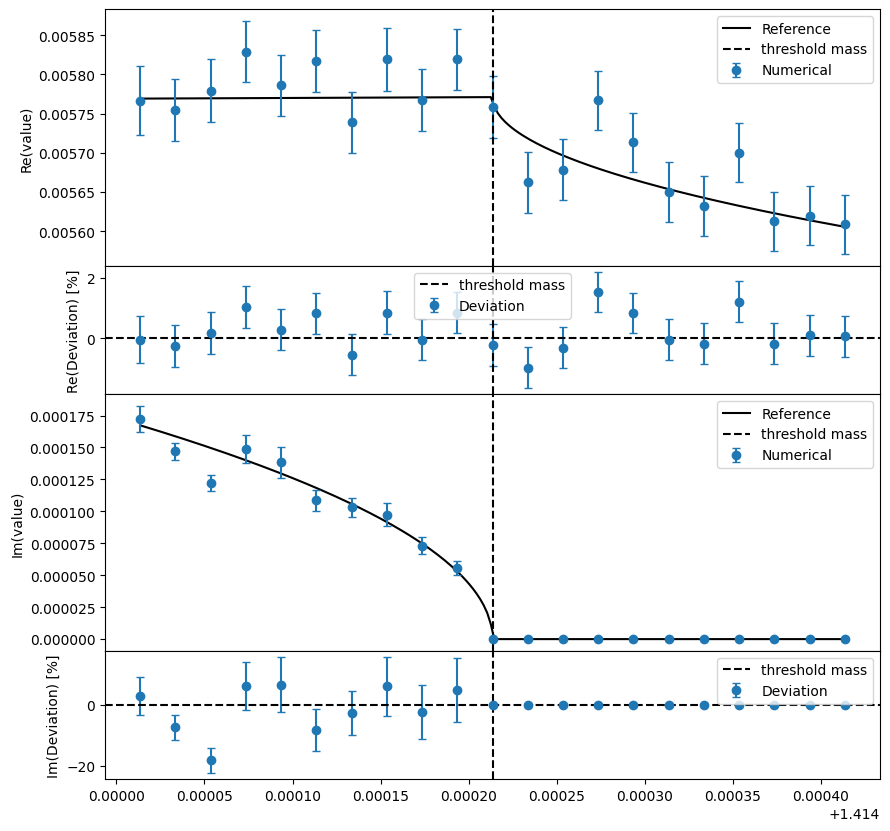

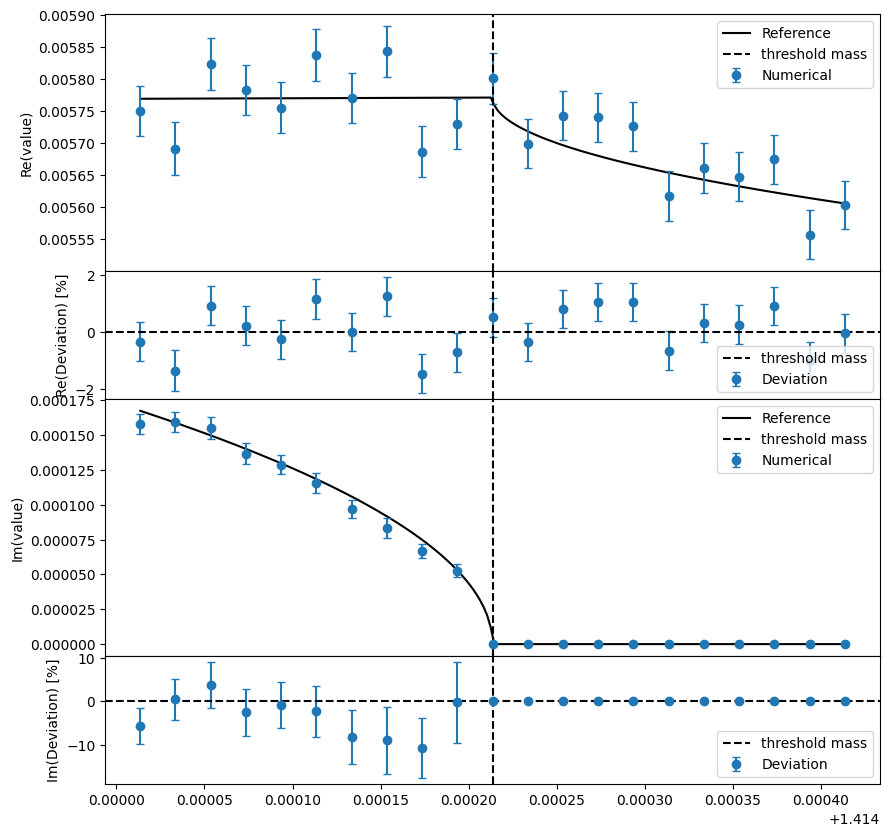

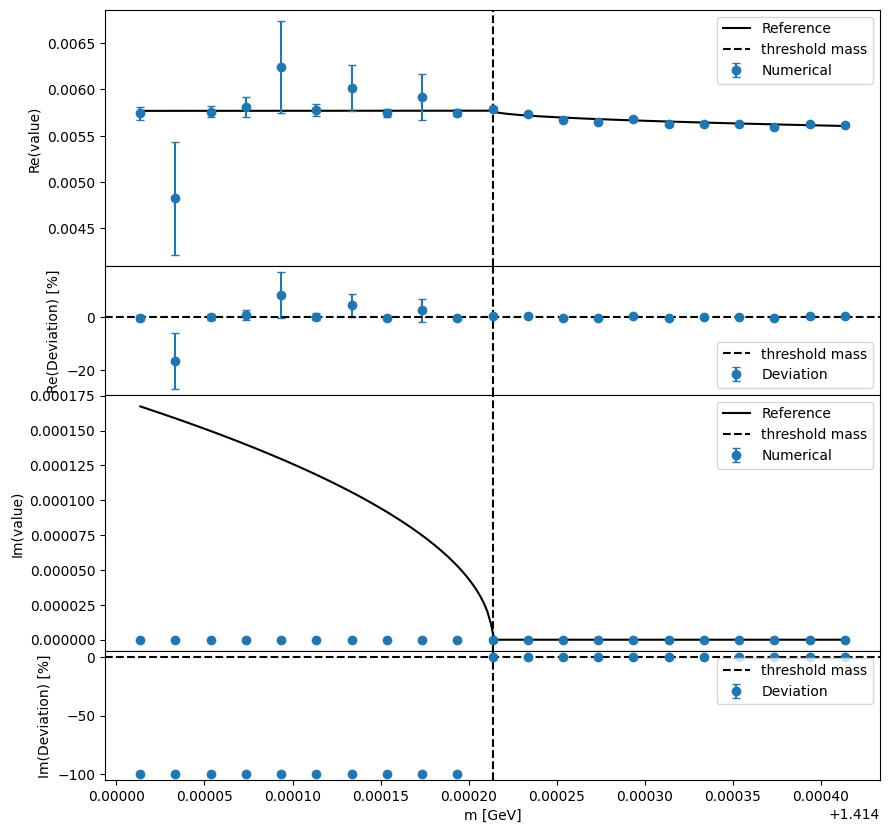

In [12]:
from plot_util import plot_complex_integration_with_ref


ref = reference_over_masses(ref_masses)
ref_same_x = reference_over_masses(sample_masses)

fig = plot_complex_integration_with_ref(
    global_check_res, ref_same_x, sample_masses, ref, ref_masses
)
for ax in fig.get_axes():
    ax.axvline(threshold_masses[2], ls = "--", c = "black", label = 'threshold mass')
    ax.legend()
plt.savefig(f"../images/threshold_masses/global_check_zoomed.png", dpi=300)
plt.show()

fig = plot_complex_integration_with_ref(
    per_sample_check, ref_same_x, sample_masses, ref, ref_masses
)
for ax in fig.get_axes():
    ax.axvline(threshold_masses[2], ls = "--", c = "black", label = 'threshold mass')
    ax.legend()
plt.savefig(f"../images/threshold_masses/per_sample_check_zoomed.png", dpi=300)
plt.show()

if complex_dist is not None:
    fig = plot_complex_integration_with_ref(
        complex_dist_res, ref_same_x, sample_masses, ref, ref_masses
    )
    for ax in fig.get_axes():
        ax.axvline(threshold_masses[2], ls = "--", c = "black", label = 'threshold mass')
        ax.legend()
    plt.savefig(f"../images/threshold_masses/variable_zoomed.png", dpi=300)
    plt.show()

fig = plot_complex_integration_with_ref(
    unsubtracted_res, ref_same_x, sample_masses, ref, ref_masses
)
for ax in fig.get_axes():
    ax.axvline(threshold_masses[2], ls = "--", c = "black", label = 'threshold mass')
    ax.legend()
fig.get_axes()[-1].set_xlabel('m')
plt.savefig(f"../images/threshold_masses/unsubtracted_zoomed.png", dpi=300)
plt.xlabel('m [GeV]')
plt.show()

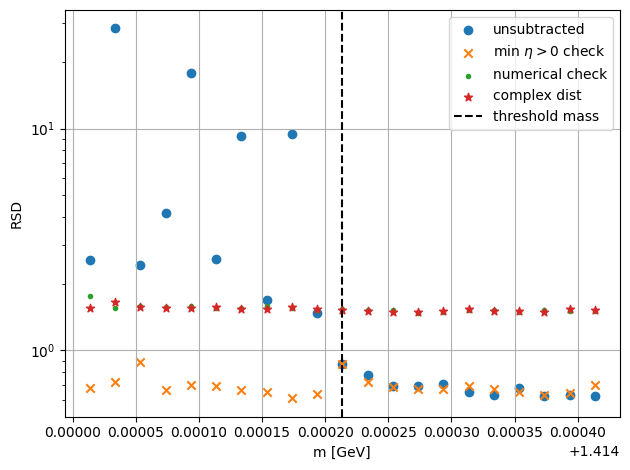

In [13]:
plt.scatter(sample_masses, [r.rsd() for r in unsubtracted_res], label = 'unsubtracted', marker='o')
plt.scatter(sample_masses, [r.rsd() for r in global_check_res], label = 'min $\\eta > 0$ check', marker = 'x')
plt.scatter(sample_masses, [r.rsd() for r in per_sample_check], label = 'numerical check', marker = '.')
if complex_dist is not None:
    plt.scatter(sample_masses, [r.rsd() for r in complex_dist_res], label = 'complex dist', marker = '*')
plt.yscale('log')
plt.axvline(threshold_masses[2], ls = "--", c = "black", label = 'threshold mass')
plt.grid(True)
plt.xlabel('m [GeV]')
plt.ylabel('RSD')
plt.legend()
plt.tight_layout()

plt.savefig(f"../images/threshold_masses/rsd_zoomed.png", dpi=300)
plt.show()
